In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import pickle

max_length = 1024  
df = pd.read_csv('all.csv', encoding='latin-1')



2025-03-26 07:50:33.364235: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742968233.380938    8998 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742968233.385792    8998 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-26 07:50:33.402117: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
#remove all rows with empty text
df = df.dropna(subset=['text'])

In [3]:
df['text'] = df['text'].str.lower()
df.head()

,text,label
0,"final doctor appointment tomorrow, tired of co...",Anxiety
1,anyone have bone or muscle pain that was stres...,Anxiety
2,listening to your body? i'm curious how those ...,Anxiety
3,weekly /r/healthanxiety challenge - exercise a...,Anxiety
4,this is killing me so i had a bacterial stomac...,Anxiety


In [4]:
import string
def remove_punctuation(text):
    punctuation=string.punctuation
    return text.translate(str.maketrans('', '', punctuation))

df['text']=df['text'].apply(lambda x: remove_punctuation(x))
df.head()


,text,label
0,final doctor appointment tomorrow tired of con...,Anxiety
1,anyone have bone or muscle pain that was stres...,Anxiety
2,listening to your body im curious how those of...,Anxiety
3,weekly rhealthanxiety challenge exercise a li...,Anxiety
4,this is killing me so i had a bacterial stomac...,Anxiety


In [5]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stopwords = set(stopwords.words('english'))

def remove_stopwords(text):
    return ' '.join([word for word in text.split() if word not in stopwords])

df['text']=df['text'].apply(lambda x: remove_stopwords(x))
df.head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,text,label
0,final doctor appointment tomorrow tired consta...,Anxiety
1,anyone bone muscle pain stressanxiety induced ...,Anxiety
2,listening body im curious us health anxiety li...,Anxiety
3,weekly rhealthanxiety challenge exercise littl...,Anxiety
4,killing bacterial stomach infectionpain right ...,Anxiety


In [6]:
from collections import Counter
word_count = Counter()
for text in df['text'].values:
    for word in text.split():
        word_count[word] += 1

word_count.most_common(10)

[('like', 6607),
 ('feel', 5266),
 ('im', 4586),
 ('get', 4417),
 ('know', 4257),
 ('anxiety', 4159),
 ('time', 3870),
 ('wa', 3814),
 ('want', 3230),
 ('really', 3183)]

In [7]:
ferquent_words = set([word for (word, count) in word_count.most_common(10)])
def remove_frequent_words(text):
    return ' '.join([word for word in text.split() if word not in ferquent_words])

df['text']=df['text'].apply(lambda x: remove_frequent_words(x))
df.head()

,text,label
0,final doctor appointment tomorrow tired consta...,Anxiety
1,anyone bone muscle pain stressanxiety induced ...,Anxiety
2,listening body curious us health listen bodies...,Anxiety
3,weekly rhealthanxiety challenge exercise littl...,Anxiety
4,killing bacterial stomach infectionpain right ...,Anxiety


In [8]:
import re

def remove_spl_char(text):
    text = re.sub('[^A-Za-z0-9]+', ' ', text)
    text = re.sub('\s+', ' ', text).strip()
    return text

df['text']=df['text'].apply(lambda x: remove_spl_char(x))
df.head()

,text,label
0,final doctor appointment tomorrow tired consta...,Anxiety
1,anyone bone muscle pain stressanxiety induced ...,Anxiety
2,listening body curious us health listen bodies...,Anxiety
3,weekly rhealthanxiety challenge exercise littl...,Anxiety
4,killing bacterial stomach infectionpain right ...,Anxiety


In [10]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet

lter = WordNetLemmatizer()
def lemmatize_words(text):
    pos_dict = {'N': wordnet.NOUN, 'V': wordnet.VERB, 'R': wordnet.ADV, 'J': wordnet.ADJ}
    words = text.split()
    tagged_words = pos_tag(words)
    return ' '.join([lter.lemmatize(word, pos_dict.get(pos[0], wordnet.NOUN)) for word, pos in tagged_words])

df['lemmatized_text'] = df['text'].apply(lambda x: lemmatize_words(x))
df.head()


,text,label,lemmatized_text
0,final doctor appointment tomorrow tired consta...,Anxiety,final doctor appointment tomorrow tire constan...
1,anyone bone muscle pain stressanxiety induced ...,Anxiety,anyone bone muscle pain stressanxiety induce i...
2,listening body curious us health listen bodies...,Anxiety,listen body curious u health listen body seem ...
3,weekly rhealthanxiety challenge exercise littl...,Anxiety,weekly rhealthanxiety challenge exercise littl...
4,killing bacterial stomach infectionpain right ...,Anxiety,kill bacterial stomach infectionpain right sid...


In [11]:
def remove_numbers(text):
    return ' '.join([word for word in text.split() if not word.isdigit()])
df['final_text']=df['lemmatized_text'].apply(lambda x: remove_numbers(x))
df.head()


,text,label,lemmatized_text,final_text
0,final doctor appointment tomorrow tired consta...,Anxiety,final doctor appointment tomorrow tire constan...,final doctor appointment tomorrow tire constan...
1,anyone bone muscle pain stressanxiety induced ...,Anxiety,anyone bone muscle pain stressanxiety induce i...,anyone bone muscle pain stressanxiety induce i...
2,listening body curious us health listen bodies...,Anxiety,listen body curious u health listen body seem ...,listen body curious u health listen body seem ...
3,weekly rhealthanxiety challenge exercise littl...,Anxiety,weekly rhealthanxiety challenge exercise littl...,weekly rhealthanxiety challenge exercise littl...
4,killing bacterial stomach infectionpain right ...,Anxiety,kill bacterial stomach infectionpain right sid...,kill bacterial stomach infectionpain right sid...


In [12]:
def remove_url(text):
    return re.sub(r'http?://\S+|www\. \S+', '', text)
df['final_text']=df['final_text'].apply(lambda x: remove_url(x))
df.head()


,text,label,lemmatized_text,final_text
0,final doctor appointment tomorrow tired consta...,Anxiety,final doctor appointment tomorrow tire constan...,final doctor appointment tomorrow tire constan...
1,anyone bone muscle pain stressanxiety induced ...,Anxiety,anyone bone muscle pain stressanxiety induce i...,anyone bone muscle pain stressanxiety induce i...
2,listening body curious us health listen bodies...,Anxiety,listen body curious u health listen body seem ...,listen body curious u health listen body seem ...
3,weekly rhealthanxiety challenge exercise littl...,Anxiety,weekly rhealthanxiety challenge exercise littl...,weekly rhealthanxiety challenge exercise littl...
4,killing bacterial stomach infectionpain right ...,Anxiety,kill bacterial stomach infectionpain right sid...,kill bacterial stomach infectionpain right sid...


In [13]:
def remove_html(text):
    return re.sub(r'<.*?>', '', text)
df['final_text']=df['final_text'].apply(lambda x: remove_html(x))
df.head()

,text,label,lemmatized_text,final_text
0,final doctor appointment tomorrow tired consta...,Anxiety,final doctor appointment tomorrow tire constan...,final doctor appointment tomorrow tire constan...
1,anyone bone muscle pain stressanxiety induced ...,Anxiety,anyone bone muscle pain stressanxiety induce i...,anyone bone muscle pain stressanxiety induce i...
2,listening body curious us health listen bodies...,Anxiety,listen body curious u health listen body seem ...,listen body curious u health listen body seem ...
3,weekly rhealthanxiety challenge exercise littl...,Anxiety,weekly rhealthanxiety challenge exercise littl...,weekly rhealthanxiety challenge exercise littl...
4,killing bacterial stomach infectionpain right ...,Anxiety,kill bacterial stomach infectionpain right sid...,kill bacterial stomach infectionpain right sid...


In [14]:
#remove all emojis

def remove_emojis(text):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)
df['final_text']=df['final_text'].apply(lambda x: remove_emojis(x))
df.head()

,text,label,lemmatized_text,final_text
0,final doctor appointment tomorrow tired consta...,Anxiety,final doctor appointment tomorrow tire constan...,final doctor appointment tomorrow tire constan...
1,anyone bone muscle pain stressanxiety induced ...,Anxiety,anyone bone muscle pain stressanxiety induce i...,anyone bone muscle pain stressanxiety induce i...
2,listening body curious us health listen bodies...,Anxiety,listen body curious u health listen body seem ...,listen body curious u health listen body seem ...
3,weekly rhealthanxiety challenge exercise littl...,Anxiety,weekly rhealthanxiety challenge exercise littl...,weekly rhealthanxiety challenge exercise littl...
4,killing bacterial stomach infectionpain right ...,Anxiety,kill bacterial stomach infectionpain right sid...,kill bacterial stomach infectionpain right sid...


In [15]:
from spellchecker import SpellChecker
spell = SpellChecker()
def correct_spellings(text):
    corrected_text = []
    misspelled_words = spell.unknown(text.split())
    for word in text.split():
        if word in misspelled_words:
            correction = spell.correction(word)
            # If no correction is found, keep the original word
            corrected_text.append(correction if correction else word)
        else:
            corrected_text.append(word)
    return " ".join(corrected_text)

df['final_text']=df['final_text'].apply(lambda x: correct_spellings(x))
df.head()

,text,label,lemmatized_text,final_text
0,final doctor appointment tomorrow tired consta...,Anxiety,final doctor appointment tomorrow tire constan...,final doctor appointment tomorrow tire constan...
1,anyone bone muscle pain stressanxiety induced ...,Anxiety,anyone bone muscle pain stressanxiety induce i...,anyone bone muscle pain stressanxiety induce g...
2,listening body curious us health listen bodies...,Anxiety,listen body curious u health listen body seem ...,listen body curious u health listen body seem ...
3,weekly rhealthanxiety challenge exercise littl...,Anxiety,weekly rhealthanxiety challenge exercise littl...,weekly rhealthanxiety challenge exercise littl...
4,killing bacterial stomach infectionpain right ...,Anxiety,kill bacterial stomach infectionpain right sid...,kill bacterial stomach infectionpain right sid...


In [16]:
#save the data 
df.to_csv('cleaned_data.csv', index=False)

In [17]:
# Preprocess data
texts = df['final_text'].values
labels = df['label'].values

# Encode labels
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)
num_classes = len(label_encoder.classes_)
y = to_categorical(encoded_labels)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    texts, y, test_size=0.1, random_state=42
)

In [18]:

def load_glove_embeddings(word_index, embedding_dim=100):
    """
    Load GloVe embeddings for the words in our vocabulary
    """
    embeddings_index = {}
    with open(f'glove.6B.{embedding_dim}d.txt', encoding='utf-8') as f:
        for line in f:
            word, coefs = line.split(maxsplit=1)
            coefs = np.fromstring(coefs, 'f', sep=' ')
            embeddings_index[word] = coefs

    embedding_matrix = np.zeros((len(word_index) + 1, embedding_dim))
    for word, i in word_index.items():
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector
    
    return embedding_matrix

# After tokenizing your text data and getting word_index from tokenizer
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['final_text'])
word_index = tokenizer.word_index

# Load GloVe embeddings
embedding_dim = 300
embedding_matrix = load_glove_embeddings(word_index, embedding_dim)

# Modify your model to use GloVe embeddings
model = Sequential([
    Embedding(len(word_index) + 1,
              embedding_dim,
              weights=[embedding_matrix],
              input_length=max_length,
              trainable=False),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')  # Replace num_classes with your number of classes
])

# Convert text to sequences and pad them
train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences = tokenizer.texts_to_sequences(X_test)


X_train_padded = pad_sequences(train_sequences, maxlen=max_length, padding='post', truncating='post')
X_test_padded = pad_sequences(test_sequences, maxlen=max_length, padding='post', truncating='post')


model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy'])

# Train the model
history = model.fit(
    X_train_padded, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# Evaluate on test data
y_pred = model.predict(X_test_padded)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

model.summary()

/home/gutz/miniconda3/envs/tf/lib/python3.9/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1742984212.269013    8998 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2248 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:29:00.0, compute capability: 7.5


Epoch 1/10


I0000 00:00:1742984217.552204   30317 cuda_dnn.cc:529] Loaded cuDNN version 90300


83/83 ━━━━━━━━━━━━━━━━━━━━ 52s 578ms/step - accuracy: 0.5077 - loss: 1.1455 - val_accuracy: 0.7263 - val_loss: 0.7165
Epoch 2/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 44s 527ms/step - accuracy: 0.7325 - loss: 0.6997 - val_accuracy: 0.7168 - val_loss: 0.6818
Epoch 3/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 44s 530ms/step - accuracy: 0.7759 - loss: 0.5985 - val_accuracy: 0.7716 - val_loss: 0.5960
Epoch 4/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 47s 567ms/step - accuracy: 0.8069 - loss: 0.5329 - val_accuracy: 0.7739 - val_loss: 0.5697
Epoch 5/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 44s 536ms/step - accuracy: 0.8295 - loss: 0.4721 - val_accuracy: 0.7906 - val_loss: 0.5623
Epoch 6/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 43s 519ms/step - accuracy: 0.8358 - loss: 0.4587 - val_accuracy: 0.8040 - val_loss: 0.5474
Epoch 7/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 43s 523ms/step - accuracy: 0.8621 - loss: 0.3816 - val_accuracy: 0.8074 - val_loss: 0.5266
Epoch 8/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 47s 565ms/step - accuracy: 0.8809 - loss: 0.3399 - val_accuracy: 0.799

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 1024, 300)      │     7,185,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 1024, 128)      │       186,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,883,150 (30.07 MB)

 Trainable params: 232,516 (908.27 KB)

 Non-trainable params: 7,185,600 (27.41 MB)

 Optimizer params: 465,034 (1.77 MB)

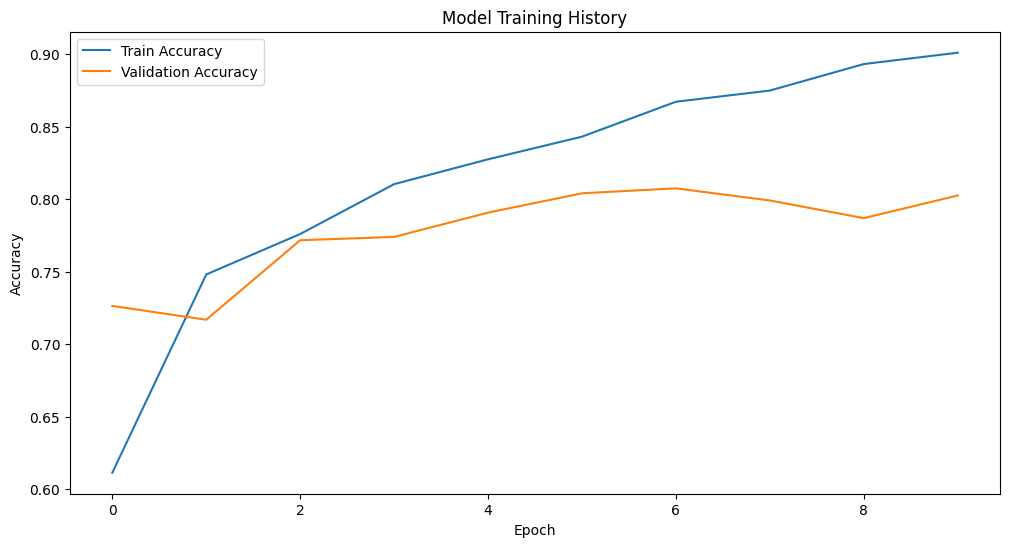

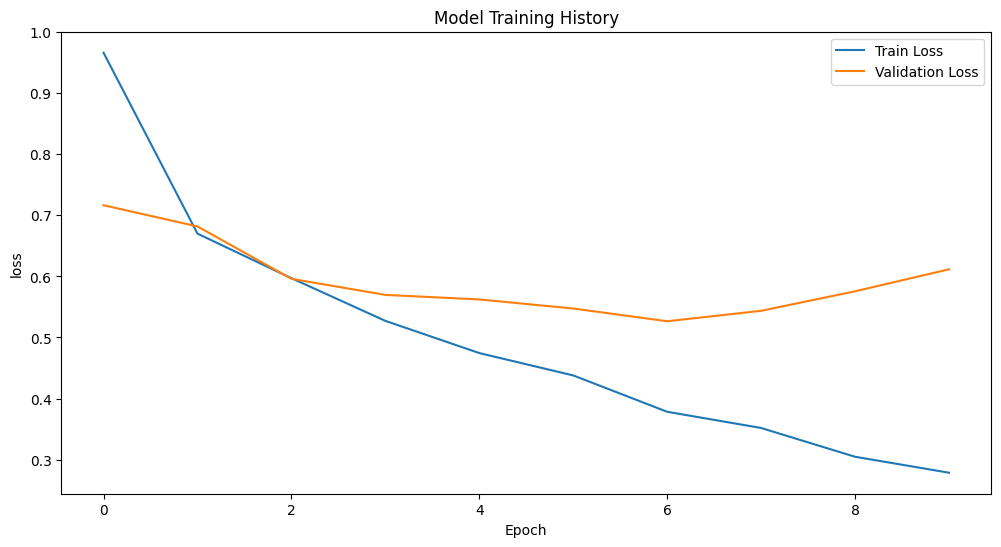

46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 154ms/step

Classification Report:
              precision    recall  f1-score   support

     Anxiety       0.89      0.80      0.84       184
  Depression       0.80      0.86      0.83       395
      Normal       0.85      0.85      0.85       616
      Stress       0.64      0.63      0.63       264

    accuracy                           0.80      1459
   macro avg       0.79      0.78      0.79      1459
weighted avg       0.80      0.80      0.80      1459



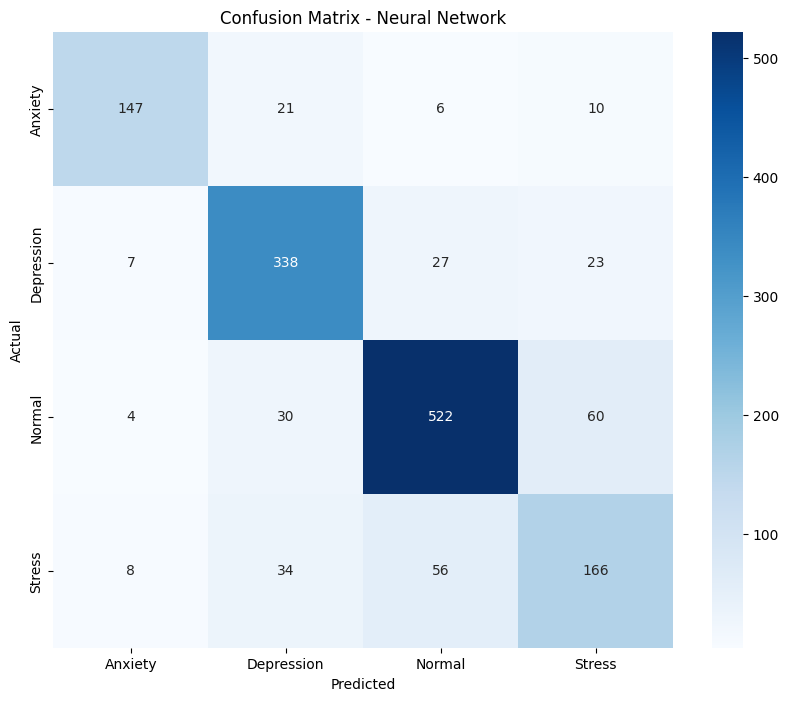

In [19]:
# --------------------- Step 8: Evaluation ---------------------
# Plot training history
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Training History')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()
# Plot training history
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Training History')
plt.ylabel('loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# Generate predictions
y_probs = model.predict(X_test_padded)
y_pred = np.argmax(y_probs, axis=1)

# Convert one-hot encoded test labels back to original format
y_test_original = np.argmax(y_test, axis=1)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_original, y_pred, target_names=label_encoder.classes_))

# Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    confusion_matrix(y_test_original, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title('Confusion Matrix - Neural Network')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [20]:
# Save the model and tokenizer
model.save('mental_health_model.h5')
model.save('mental_health_model.keras')
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)


In [21]:
import pickle
import tensorflow as tf
from tensorflow.keras.models import load_model

# Load the tokenizer
with open('tokenizer.pickle', 'rb') as handle:
    tokenizer = pickle.load(handle)

max_length = 1024 
moods = ["Anxiety", "Depression", "Normal","Stress"]

# Load the model
model = load_model('mental_health_model.h5')

# Example prediction
new_text = ["worried tetanus sort ton change rusty old arm felt itchy scratch pretty hard break little piece skin realize stupid mistake wash hand well area arm soap water leave side head neck little warm hurt could possibly tetanus"]
new_sequence = tokenizer.texts_to_sequences(new_text)
new_padded = pad_sequences(new_sequence, maxlen=max_length, padding='post', truncating='post')
prediction = model.predict(new_padded)
predicted_class = moods[np.argmax(prediction[0])]

print(f"Predicted Label: {predicted_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 522ms/step
Predicted Label: Anxiety
